In [24]:
import numpy as np
import pandas as pd

In [25]:
df=pd.read_csv("Job_Placement_Data.csv")

In [26]:
df.head(8)

,gender,ssc_percentage,ssc_board,hsc_percentage,hsc_board,hsc_subject,degree_percentage,undergrad_degree,work_experience,emp_test_percentage,specialisation,mba_percent,status
0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.00,Mkt&HR,58.80,Placed
1,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.50,Mkt&Fin,66.28,Placed
2,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.00,Mkt&Fin,57.80,Placed
3,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.00,Mkt&HR,59.43,Not Placed
4,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.80,Mkt&Fin,55.50,Placed
5,M,55.00,Others,49.80,Others,Science,67.25,Sci&Tech,Yes,55.00,Mkt&Fin,51.58,Not Placed
6,F,46.00,Others,49.20,Others,Commerce,79.00,Comm&Mgmt,No,74.28,Mkt&Fin,53.29,Not Placed
7,M,82.00,Central,64.00,Central,Science,66.00,Sci&Tech,Yes,67.00,Mkt&Fin,62.14,Placed


In [27]:
df.shape

(215, 13)

In [28]:
df.isnull().sum()

gender                 0
ssc_percentage         0
ssc_board              0
hsc_percentage         0
hsc_board              0
hsc_subject            0
degree_percentage      0
undergrad_degree       0
work_experience        0
emp_test_percentage    0
specialisation         0
mba_percent            0
status                 0
dtype: int64

In [29]:
df.duplicated().sum()

0

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               215 non-null    object 
 1   ssc_percentage       215 non-null    float64
 2   ssc_board            215 non-null    object 
 3   hsc_percentage       215 non-null    float64
 4   hsc_board            215 non-null    object 
 5   hsc_subject          215 non-null    object 
 6   degree_percentage    215 non-null    float64
 7   undergrad_degree     215 non-null    object 
 8   work_experience      215 non-null    object 
 9   emp_test_percentage  215 non-null    float64
 10  specialisation       215 non-null    object 
 11  mba_percent          215 non-null    float64
 12  status               215 non-null    object 
dtypes: float64(5), object(8)
memory usage: 22.0+ KB


In [31]:
df.describe() # onlyy numercial b features shown krta hai show krta hai 

,ssc_percentage,hsc_percentage,degree_percentage,emp_test_percentage,mba_percent
count,215.000000,215.000000,215.000000,215.000000,215.000000
mean,67.303395,66.333163,66.370186,72.100558,62.278186
std,10.827205,10.897509,7.358743,13.275956,5.833385
min,40.890000,37.000000,50.000000,50.000000,51.210000
25%,60.600000,60.900000,61.000000,60.000000,57.945000
50%,67.000000,65.000000,66.000000,71.000000,62.000000
75%,75.700000,73.000000,72.000000,83.500000,66.255000
max,89.400000,97.700000,91.000000,98.000000,77.890000


In [32]:
df1=df[["gender","ssc_percentage","hsc_percentage","degree_percentage","mba_percent","work_experience","status"]]

In [33]:
df1.head(1)

,gender,ssc_percentage,hsc_percentage,degree_percentage,mba_percent,work_experience,status
0,M,67.0,91.0,58.0,58.8,No,Placed


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

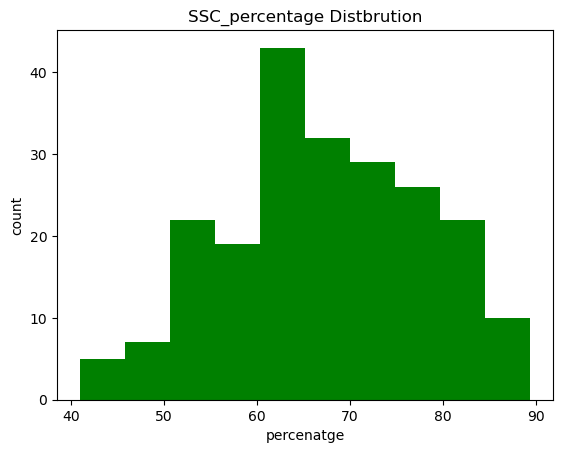

In [35]:

plt.hist(df1["ssc_percentage"],bins=10,color="green" )
plt.title("SSC_percentage Distbrution")
plt.xlabel("percenatge")
plt.ylabel("count")
plt.show()

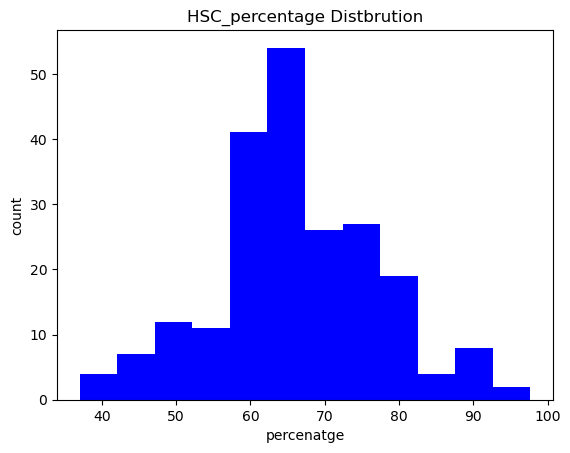

In [36]:

plt.hist(df1["hsc_percentage"],color="blue",bins=12 )
plt.title("HSC_percentage Distbrution")

plt.xlabel("percenatge")
plt.ylabel("count")
plt.show()

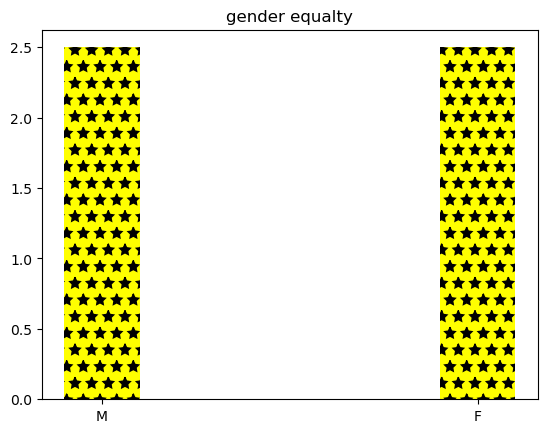

In [37]:
plt.bar(df1["gender"] ,height=2.5 ,linewidth=3,width=0.2,hatch="*" ,color="yellow")
plt.title("gender equalty")

plt.show()

<Axes: xlabel='ssc_percentage', ylabel='hsc_percentage'>

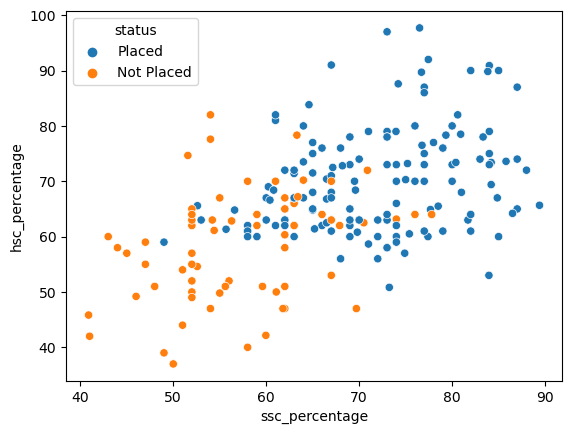

In [38]:
sns.scatterplot(x="ssc_percentage",y="hsc_percentage",data=df,hue="status")

In [39]:

df["status"].value_counts() #how many placments there is huge gap thatr data is unalance

status
Placed        148
Not Placed     67
Name: count, dtype: int64

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               215 non-null    object 
 1   ssc_percentage       215 non-null    float64
 2   ssc_board            215 non-null    object 
 3   hsc_percentage       215 non-null    float64
 4   hsc_board            215 non-null    object 
 5   hsc_subject          215 non-null    object 
 6   degree_percentage    215 non-null    float64
 7   undergrad_degree     215 non-null    object 
 8   work_experience      215 non-null    object 
 9   emp_test_percentage  215 non-null    float64
 10  specialisation       215 non-null    object 
 11  mba_percent          215 non-null    float64
 12  status               215 non-null    object 
dtypes: float64(5), object(8)
memory usage: 22.0+ KB


In [41]:
#convert caterg int numd
mapping_dict = {
    'gender': {'Male': 1, 'Female': 0},
    'status': {' Not Placed': 0, ' Placed': 1},
    'work_experience': {'Yes': 1, 'No': 0}
}
df1_mapped = df1.replace(mapping_dict)

df2=pd.get_dummies(df1_mapped ,drop_first=True).astype(int)


In [42]:
df2.shape

(215, 7)

In [43]:
df2.head(13)

,ssc_percentage,hsc_percentage,degree_percentage,mba_percent,work_experience,gender_M,status_Placed
0,67,91,58,58,0,1,1
1,79,78,77,66,1,1,1
2,65,68,64,57,0,1,1
3,56,52,52,59,0,1,0
4,85,73,73,55,0,1,1
5,55,49,67,51,1,1,0
6,46,49,79,53,0,0,0
7,82,64,66,62,1,1,1
8,73,79,72,61,0,1,1
9,58,70,61,52,0,1,0


In [44]:
#train test split
x=df2.drop(["status_Placed"],axis=1)
y=df2["status_Placed"]
print(x.shape,"\n\n",y.shape)


(215, 6) 

 (215,)


In [45]:
from  sklearn.model_selection import train_test_split

In [46]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [47]:
x_train.shape

(172, 6)

In [48]:
x_test.shape

(43, 6)

In [49]:
#train model
from sklearn.linear_model import LogisticRegression
lg=LogisticRegression()

In [50]:
lg.fit(x_train,y_train) # 80 data
y_pred=lg.predict(x_test) # predicted by the model
y_pred

C:\Users\ANIRUDH\anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0])

In [51]:
from sklearn.metrics import accuracy_score

In [52]:
accuracy_score(y_test,y_pred)

0.8837209302325582

In [53]:
# prediction system
input_data=(56,52,52,59,0,1)
np_array=np.asarray(input_data) #convet into array
reshaped_array=np_array.reshape(1,-1)
prediction=lg.predict(reshaped_array)
if prediction[0]==1:
    print("person is placed")
else:
    print("person is not placed")

person is not placed


C:\Users\ANIRUDH\anaconda\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [54]:
import pickle
pickle.dump(lg,open("placement.pkl","wb"))